# Task 1

<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3905056/4014591562.py:76: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, stats.norm.pdf(x, 0, 1), 'k--', lw=2, label="$\mathcal{N}(0,1)$")


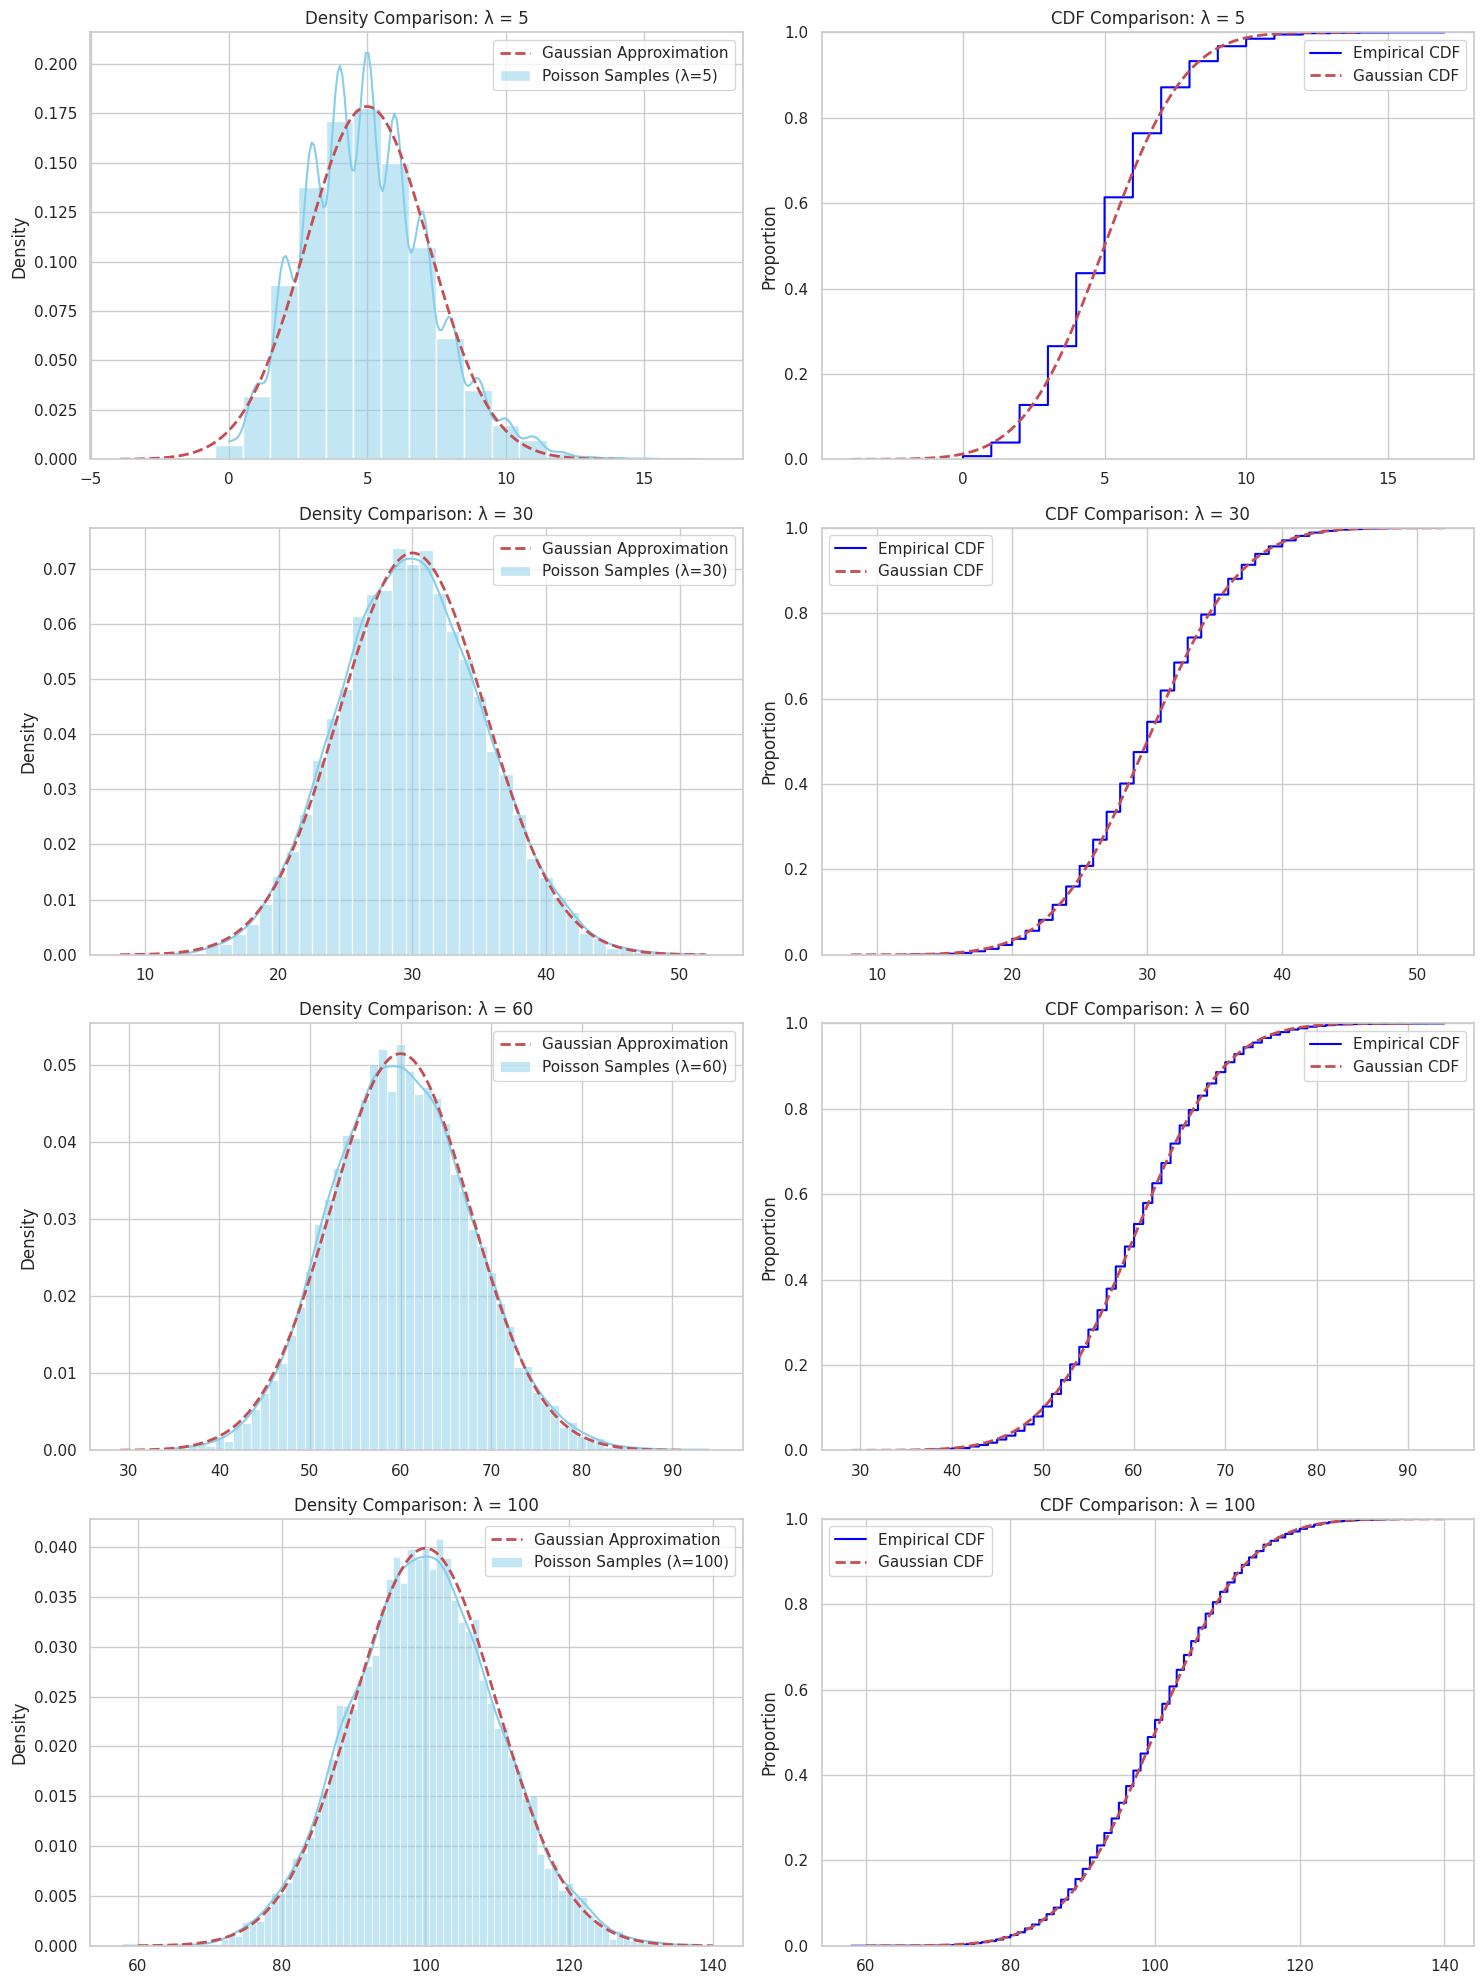

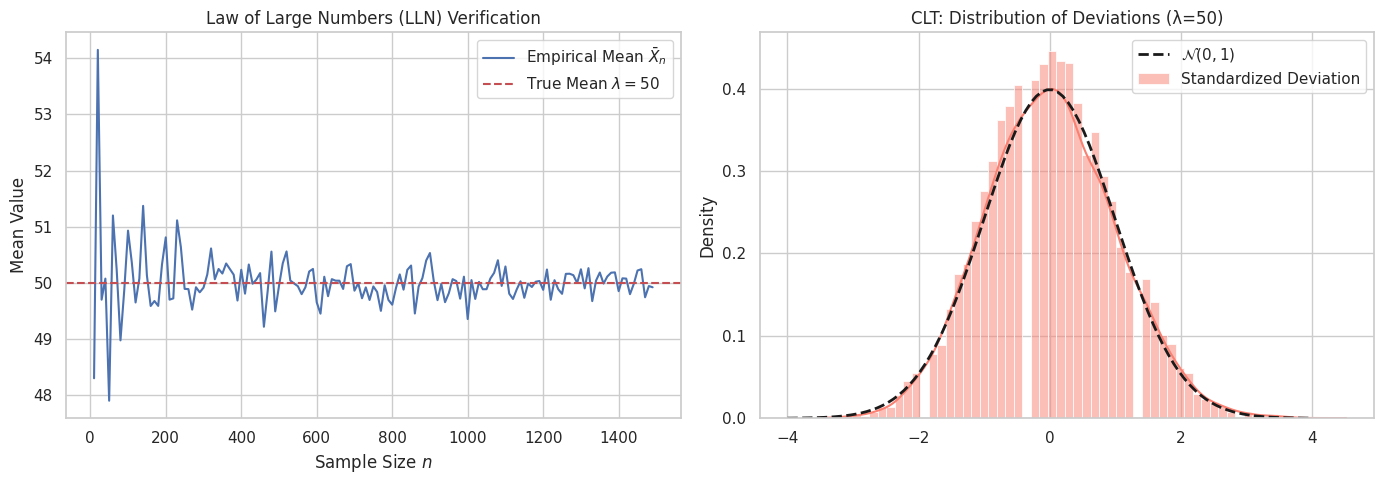

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# set the style of plot
sns.set_theme(style="whitegrid")
np.random.seed(42)

def simulate_poisson_approximation(lambdas):
    """
    task 1 & 2: Generate samples and compare probability density (PMF/PDF) with cumulative distribution (CDF)
    """
    fig, axes = plt.subplots(len(lambdas), 2, figsize=(15, 5 * len(lambdas)))
    
    for i, lam in enumerate(lambdas):
        # 1. Generate samples from the Poisson distribution 
        size = 10000
        samples = np.random.poisson(lam, size)
        
        # Define the continuous x-axis for drawing the Gaussian curve
        x_continuous = np.linspace(lam - 4*np.sqrt(lam), lam + 4*np.sqrt(lam), 500)
        # Define the discrete x-axis for the Poisson PMF
        x_discrete = np.arange(int(max(0, lam - 4*np.sqrt(lam))), int(lam + 4*np.sqrt(lam)) + 1)
        
        # --- Left image: Probability density/distribution comparison (Smoothed Histogram vs PDF) ---
        # Use a smoothed histogram to display the sample distribution 
        sns.histplot(samples, kde=True, stat="density", color="skyblue", 
                     label=f"Poisson Samples (λ={lam})", ax=axes[i, 0], discrete=True)
        # Superimposed Gaussian Probability Density Function (PDF)
        gauss_pdf = stats.norm.pdf(x_continuous, loc=lam, scale=np.sqrt(lam))
        axes[i, 0].plot(x_continuous, gauss_pdf, 'r--', lw=2, label="Gaussian Approximation")
        axes[i, 0].set_title(f"Density Comparison: λ = {lam}")
        axes[i, 0].legend()

        # --- Right figure: Comparison of cumulative distribution functions (Empirical CDF vs Theoretical CDF) --- 
        # Experience cumulative distribution
        sns.ecdfplot(samples, color="blue", label="Empirical CDF", ax=axes[i, 1])
        # Gaussian cumulative distribution
        gauss_cdf = stats.norm.cdf(x_continuous, loc=lam, scale=np.sqrt(lam))
        axes[i, 1].plot(x_continuous, gauss_cdf, 'r--', lw=2, label="Gaussian CDF")
        axes[i, 1].set_title(f"CDF Comparison: λ = {lam}")
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()

def verify_lln_and_clt(lam, max_n=1500):
    """
    task 3: Verification of the Law of Large Numbers (LLN) and the Central Limit Theorem (CLT) 
    """
    # --- Verification of LLN ---
    sample_sizes = np.arange(10, max_n, 10)
    empirical_means = [np.mean(np.random.poisson(lam, n)) for n in sample_sizes]
    
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(sample_sizes, empirical_means, label="Empirical Mean $\\bar{X}_n$")
    plt.axhline(y=lam, color='r', linestyle='--', label=f"True Mean $\\lambda={lam}$")
    plt.xlabel("Sample Size $n$")
    plt.ylabel("Mean Value")
    plt.title("Law of Large Numbers (LLN) Verification")
    plt.legend()

    # --- Verification of CLT ---
    # Study the distribution of deviations: (X - λ) / sqrt(λ) 
    num_simulations = 10000
    # Here, we directly consider the univariate standardized distribution under large λ, 
    # or the distribution of the means of multiple samples.
    # Request: Study the "distribution pattern of deviations"
    standardized_deviations = (np.random.poisson(lam, num_simulations) - lam) / np.sqrt(lam)
    
    plt.subplot(1, 2, 2)
    sns.histplot(standardized_deviations, kde=True, stat="density", color="salmon", label="Standardized Deviation")
    x = np.linspace(-4, 4, 100)
    plt.plot(x, stats.norm.pdf(x, 0, 1), 'k--', lw=2, label="$\mathcal{N}(0,1)$")
    plt.title(f"CLT: Distribution of Deviations (λ={lam})")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Carry out simulation
target_lambdas = [5, 30, 60, 100] # Select representative values within the range of 1 to 10 
simulate_poisson_approximation(target_lambdas)
verify_lln_and_clt(lam=50)


<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3905056/2982646114.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Poisson Parameter $\lambda$')
/tmp/ipykernel_3905056/2982646114.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Approximation Error Decay as a function of $\lambda$')


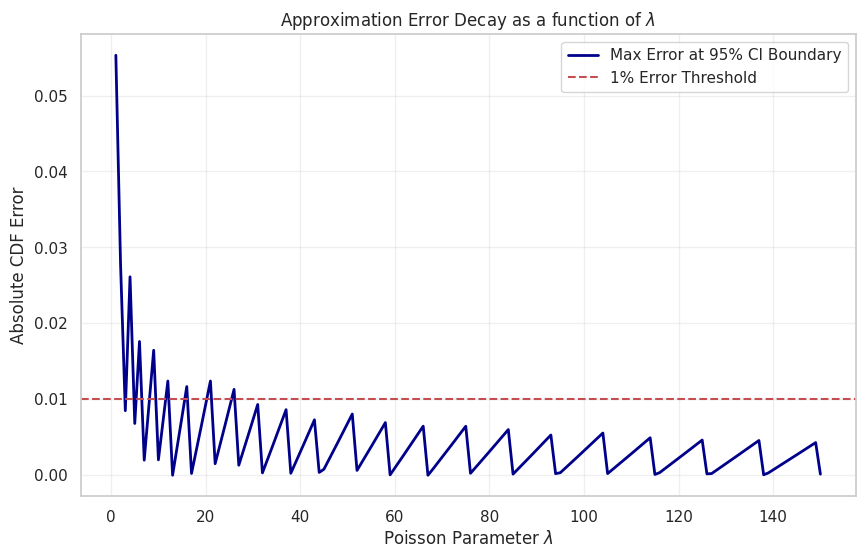

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

lambdas = np.arange(1, 151)
max_errors = []

for lam in lambdas:
    # Focus on the tail: Calculate the difference in CDF values at the 95% confidence interval boundaries
    # Select the 97.5% quantile point of the Gaussian distribution
    z_point = norm.ppf(0.975, loc=lam, scale=np.sqrt(lam))
    
    # Calculate the absolute difference between the Poisson CDF and the Gaussian CDF at this point
    error = abs(poisson.cdf(np.floor(z_point), lam) - norm.cdf(z_point, loc=lam, scale=np.sqrt(lam)))
    max_errors.append(error)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, max_errors, label='Max Error at 95% CI Boundary', color='darkblue', lw=2)
plt.axhline(y=0.01, color='r', linestyle='--', label='1% Error Threshold')
plt.xlabel('Poisson Parameter $\lambda$')
plt.ylabel('Absolute CDF Error')
plt.title('Approximation Error Decay as a function of $\lambda$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Task 3

Training Gaussian Process model and optimizing hyperparameters...

Results:
R2 Score: 0.8904
RMSE: 2.3433 dB
Kernel parameters after optimization: 1.95**2 * RBF(length_scale=1.11) + WhiteKernel(noise_level=0.106)


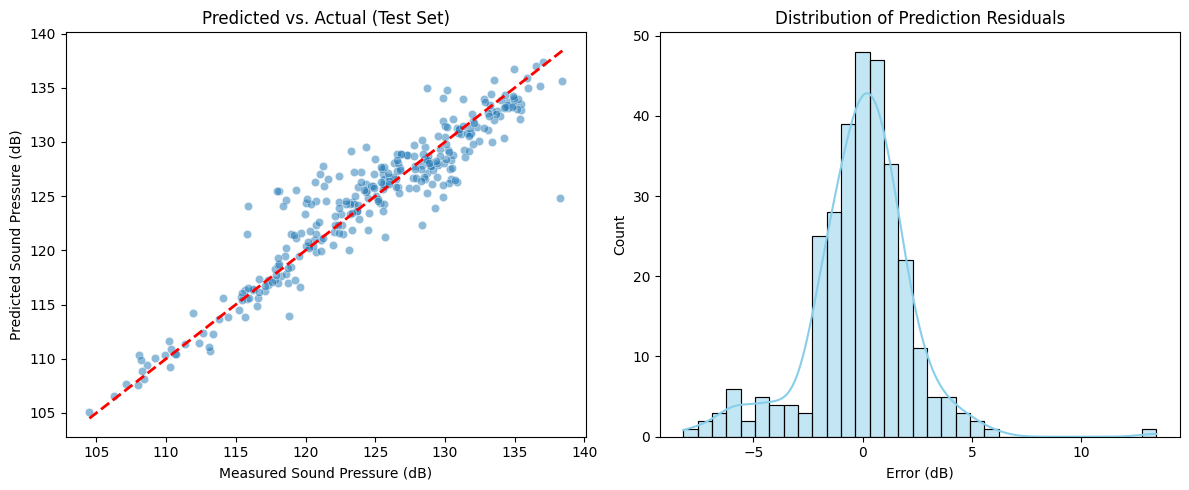

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load data (Airfoil Self-Noise Dataset)
column_names = ['Frequency', 'Angle_of_Attack', 'Chord_Length', 
                'Velocity', 'Displacement_Thickness', 'Sound_Pressure_Level']
df = pd.read_csv('airfoil_self_noise.dat', sep='\t', header=None, names=column_names)

# 2. data processing
X = df.drop('Sound_Pressure_Level', axis=1).values
y = df['Sound_Pressure_Level'].values

# Scale the features: Gaussian processes are sensitive to feature scaling (affects the interpretation of the length scale)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# 3. Model construction: Gaussian Process Regression (based on GPML 2.1.1)
# Define the kernel: signal variance * RBF kernel + white noise kernel (for estimating observation noise sigma_n^2)
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

# 4. training the model
print("Training Gaussian Process model and optimizing hyperparameters...")
gpr.fit(X_train, y_train)

# 5. Prediction and inverse scaling
y_pred_scaled, sigma_scaled = gpr.predict(X_test, return_std=True)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
# Prediction standard deviation also needs to be scaled back to the original units
sigma = sigma_scaled * scaler_y.scale_

# 6. Results evaluation
mse = mean_squared_error(y_test_orig, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_orig, y_pred)

print(f"\nResults:")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f} dB")
print(f"Kernel parameters after optimization: {gpr.kernel_}")

# 7. Visualization
plt.figure(figsize=(12, 5))

# Figure 1: Predicted vs. Actual
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_orig, y=y_pred, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Measured Sound Pressure (dB)')
plt.ylabel('Predicted Sound Pressure (dB)')
plt.title('Predicted vs. Actual (Test Set)')

# Figure 2: Distribution of Prediction Residuals
plt.subplot(1, 2, 2)
errors = y_test_orig - y_pred
sns.histplot(errors, kde=True, color='skyblue')
plt.xlabel('Error (dB)')
plt.title('Distribution of Prediction Residuals')

plt.tight_layout()
plt.show()